In [1]:
# 1. Load the data and prepare it as a time series dataset

import warnings
warnings.filterwarnings("ignore")  # Hide non-critical warnings to keep the output cleaner

import pandas as pd                 # pandas is used for handling table-like data
import numpy as np                  # numpy is used for numerical calculations
from pathlib import Path            # Path makes file paths easier to manage

# The CSV file should be saved in the same folder as this notebook.
file_path = Path("TSA_2025_2026_PROJECT_DATA_TOPIC_1.csv")
if not file_path.exists():
    file_path = Path("/Users/yuhanwen/Downloads/the project of time series/TSA_2025_2026_PROJECT_DATA_TOPIC_1.csv")

# Read the CSV file
data = pd.read_csv(file_path)

# Quickly inspect the dataset
print(data.head())
print(data.shape)
print(data.columns)

# Convert the date column into datetime format and use it as the index
data["date"] = pd.to_datetime(data["date"])
data = data.set_index("date")

# Store the names of all time series variables, such as y1, y2, ..., y10
series_cols = list(data.columns)

# Convert all columns to numeric values; invalid values will become NaN
data = data.apply(pd.to_numeric, errors="coerce")

# Check data types and missing values
print(data.dtypes)
print(data.isna().sum())

# Use the last 25 observations as the test set and the remaining observations as the training set
train = data.iloc[:-25]
test = data.iloc[-25:]

# Check the size and boundary observations of the training and test sets
print(test.shape)
print(train.shape)
print(train.tail())
print(test.head())


         date      y1      y2      y3      y4      y5      y6      y7      y8  \
0  2023-09-09  109.41  109.41  109.41  124.24  124.47  109.41  119.94  104.66   
1  2023-09-10  109.41  109.41  109.41  124.21  124.32  109.41  101.39  104.34   
2  2023-09-11  109.42  109.41  109.41  124.41  124.37  109.41   97.64  104.23   
3  2023-09-12  108.68  110.19  111.12  123.93  124.82  109.41   94.35  107.23   
4  2023-09-13  106.21  110.88  112.92  122.68  123.91  107.84   96.22  109.71   

       y9     y10  
0  107.62  119.32  
1  102.61  119.36  
2   99.16  119.38  
3  103.39  121.06  
4  102.43  122.17  
(600, 11)
Index(['date', 'y1', 'y2', 'y3', 'y4', 'y5', 'y6', 'y7', 'y8', 'y9', 'y10'], dtype='str')
y1     float64
y2     float64
y3     float64
y4     float64
y5     float64
y6     float64
y7     float64
y8     float64
y9     float64
y10    float64
dtype: object
y1     0
y2     0
y3     0
y4     0
y5     0
y6     0
y7     0
y8     0
y9     0
y10    0
dtype: int64
(25, 10)
(575, 10)
       

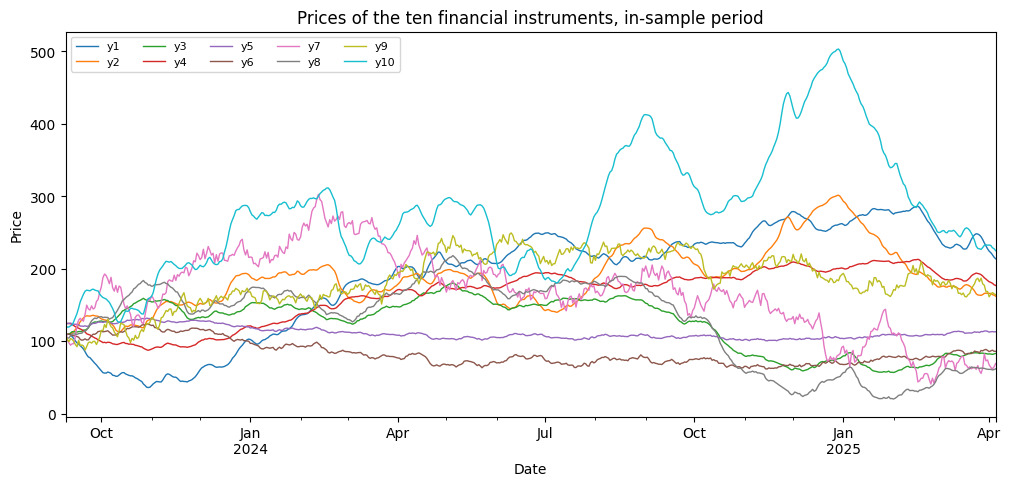

In [2]:
# 2. Plot the ten price series in the training sample

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
train.plot(ax=ax, linewidth=1)

ax.set_title("Prices of the ten financial instruments, in-sample period")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend(ncol=5, fontsize=8)

plt.show()


### Package note

This project requires `pandas`, `numpy`, `matplotlib`, and `statsmodels`. If any package is missing, run `%pip install -U pandas statsmodels` once and then restart the kernel.

In [3]:
# 3. ADF unit root tests
# Purpose: check whether each series is stationary.
# If the level series is non-stationary but the first difference is stationary, the series is likely I(1).

from statsmodels.tsa.stattools import adfuller

# Define a small function so that the ADF test can be applied repeatedly
def adf_test(x, regression="ct"):
    result = adfuller(
        x.dropna(),          # Drop missing values before running the test
        regression=regression,
        autolag="AIC",      # Select the lag length automatically by AIC
        store=False,
        regresults=False
    )

    return {
        "ADF statistic": result[0],
        "p-value": result[1],
        "used lags": result[2],
        "nobs": result[3],
    }

adf_rows = []

for col in series_cols:
    # Test the level series and its first difference
    level = adf_test(train[col], regression="ct")
    diff = adf_test(train[col].diff(), regression="c")

    adf_rows.append({
        "series": col,
        "level ADF stat": level["ADF statistic"],
        "level p-value": level["p-value"],
        "diff ADF stat": diff["ADF statistic"],
        "diff p-value": diff["p-value"],
    })

adf_table = pd.DataFrame(adf_rows).set_index("series")
adf_table.round(4)


,level ADF stat,level p-value,diff ADF stat,diff p-value
series,,,,
y1,-0.5142,0.9829,-7.7058,0.0
y2,-1.9033,0.6529,-6.5747,0.0
y3,-2.2472,0.4633,-6.3928,0.0
y4,-0.7795,0.9674,-8.5591,0.0
y5,-0.7270,0.9713,-9.8167,0.0
y6,-0.7145,0.9722,-5.8195,0.0
y7,-2.9934,0.1339,-6.7938,0.0
y8,-2.2950,0.4367,-6.6427,0.0
y9,-1.8110,0.6994,-24.4522,0.0


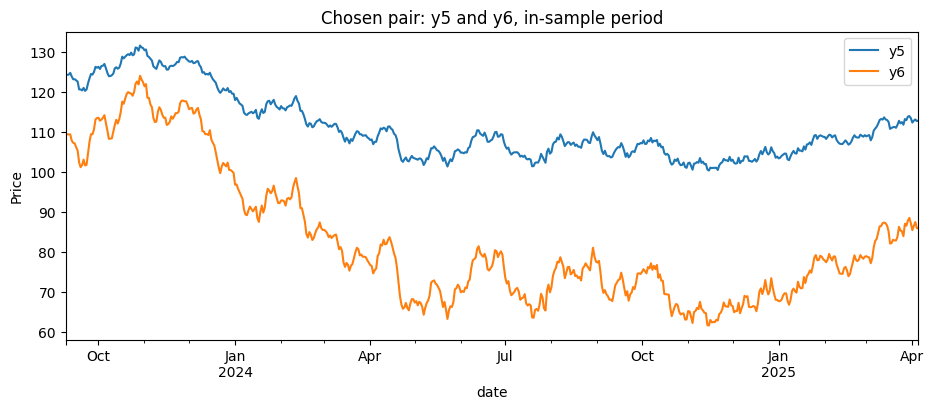

In [4]:
# 4. Pairwise cointegration screening
# Cointegration means that two non-stationary series may still share a stable long-run relationship.

from itertools import combinations
from statsmodels.tsa.stattools import coint

coint_rows = []

# Generate all possible pairs, such as y1-y2, y1-y3, and so on
for a, b in combinations(series_cols, 2):
    # If two variables are almost perfectly correlated, the cointegration test may be unreliable
    correlation = train[a].corr(train[b])
    if abs(correlation) > 0.9999:
        continue

    # Run the Engle-Granger cointegration test for the current pair
    stat, pvalue, crit = coint(train[a], train[b], trend="c", autolag="aic")

    # Skip invalid results
    if not np.isfinite(stat) or not np.isfinite(pvalue):
        continue

    coint_rows.append({
        "series 1": a,
        "series 2": b,
        "test statistic": stat,
        "p-value": pvalue,
        "5% critical value": crit[1],
    })

# Sort by p-value; a smaller p-value indicates stronger evidence of cointegration
coint_table = pd.DataFrame(coint_rows).sort_values("p-value").reset_index(drop=True)
coint_table.head(10).round(5)

# Based on the screening result, choose y5 and y6 for the VECM analysis
pair = ["y5", "y6"]

fig, ax = plt.subplots(figsize=(11, 4))
train[pair].plot(ax=ax)
ax.set_title("Chosen pair: y5 and y6, in-sample period")
ax.set_ylabel("Price")
plt.show()


Estimated long-run relation:
y5 ≈ 0.5008 * y6 + 69.6568


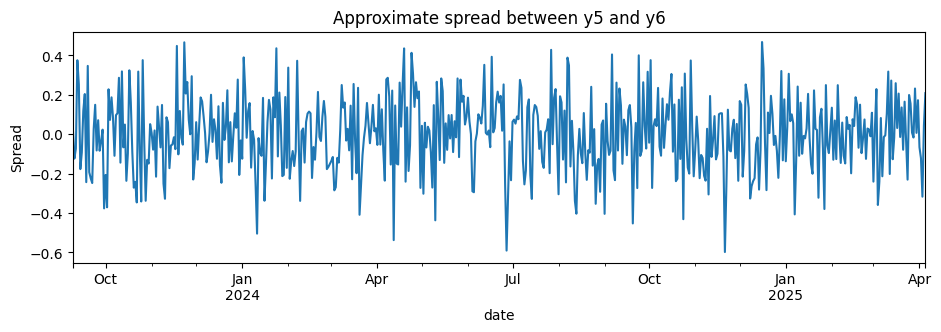

In [5]:
# 5. Plot a simple spread to visualize the long-run relation between y5 and y6
# Instead of manually using y5 - 2*y6, the hedge ratio is estimated from the data.

hedge_ratio, intercept = np.polyfit(train["y6"], train["y5"], 1)
spread = train["y5"] - (hedge_ratio * train["y6"] + intercept)

print("Estimated long-run relation:")
print(f"y5 ≈ {hedge_ratio:.4f} * y6 + {intercept:.4f}")

fig, ax = plt.subplots(figsize=(11, 3))
spread.plot(ax=ax)
ax.set_title("Approximate spread between y5 and y6")
ax.set_ylabel("Spread")
plt.show()


In [6]:
# 6. Select the lag order for the VECM
# The lag order determines how many past observations are used by the model.

from statsmodels.tsa.vector_ar.vecm import select_order

pair = ["y5", "y6"]

lag_selection = select_order(
    train[pair],
    maxlags=10,
    deterministic="ci"
)

print(lag_selection.summary())

# Use AIC to select the lag order; a lower AIC is preferred
k_ar_diff = int(lag_selection.aic)
print("Selected lag order:", k_ar_diff)


 VECM Order Selection (* highlights the minimums) 
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -2.657      -2.595     0.07019      -2.633
1       -2.689      -2.597     0.06796      -2.653
2       -2.681      -2.558     0.06849      -2.633
3       -2.673      -2.519     0.06903      -2.613
4       -2.790      -2.605     0.06145      -2.718
5       -2.844     -2.629*     0.05820     -2.760*
6       -2.835      -2.589     0.05874      -2.739
7       -2.832      -2.555     0.05890      -2.724
8       -2.853      -2.546     0.05765      -2.733
9      -2.860*      -2.522    0.05728*      -2.728
10      -2.858      -2.489     0.05740      -2.714
--------------------------------------------------
Selected lag order: 9


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

In [7]:
# 7. Johansen cointegration test
# Purpose: confirm whether y5 and y6 have a long-run equilibrium relationship.

from statsmodels.tsa.vector_ar.vecm import coint_johansen

johansen = coint_johansen(
    train[pair],
    det_order=0,
    k_ar_diff=k_ar_diff
)

johansen_table = pd.DataFrame({
    "trace statistic": johansen.lr1,
    "5% trace critical value": johansen.cvt[:, 1],
    "max eigen statistic": johansen.lr2,
    "5% max eigen critical value": johansen.cvm[:, 1],
}, index=["r = 0", "r <= 1"])

johansen_table.round(4)


,trace statistic,5% trace critical value,max eigen statistic,5% max eigen critical value
r = 0,65.2177,15.4943,63.1543,14.2639
r <= 1,2.0633,3.8415,2.0633,3.8415


In [8]:
# 8. Estimate the VECM model
# VECM captures both short-run dynamics and the adjustment toward the long-run equilibrium.

from statsmodels.tsa.vector_ar.vecm import VECM

vecm_model = VECM(
    train[pair],
    k_ar_diff=k_ar_diff,
    coint_rank=1,
    deterministic="ci"
)

vecm_res = vecm_model.fit()
print(vecm_res.summary())


Det. terms outside the coint. relation & lagged endog. parameters for equation y5
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
L1.y5         -0.1575      0.425     -0.371      0.711      -0.991       0.676
L1.y6          0.2468      0.214      1.154      0.249      -0.173       0.666
L2.y5         -0.0592      0.399     -0.148      0.882      -0.841       0.723
L2.y6         -0.0118      0.202     -0.058      0.953      -0.407       0.383
L3.y5          0.0259      0.371      0.070      0.944      -0.701       0.752
L3.y6         -0.0682      0.187     -0.365      0.715      -0.434       0.298
L4.y5         -0.1751      0.344     -0.509      0.611      -0.849       0.499
L4.y6          0.3388      0.174      1.947      0.052      -0.002       0.680
L5.y5         -0.0675      0.314     -0.215      0.830      -0.682       0.547
L5.y6         -0.1404      0.159     -0.880      

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [9]:
# 9. Extract the key VECM results: alpha and beta
# Alpha shows how each variable adjusts when the system deviates from equilibrium.
# Beta describes the long-run cointegrating relationship.

alpha = pd.DataFrame(vecm_res.alpha, index=pair, columns=["alpha"])
beta = pd.DataFrame(vecm_res.beta, index=pair, columns=["beta"])

print("Loading coefficients alpha:")
display(alpha.round(4))

print("Cointegrating vector beta:")
display(beta.round(4))

print("Cointegration constant:", float(vecm_res.det_coef_coint.ravel()[0]))


Loading coefficients alpha:


,alpha
y5,-0.9889
y6,0.2223


Cointegrating vector beta:


,beta
y5,1.0000
y6,-0.5008


Cointegration constant: -69.65557207942165


Portmanteau-test for residual autocorrelation. H_0: residual autocorrelation up to lag 12 is zero. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         18.17          18.31   0.052 10
----------------------------------------
normality (skew and kurtosis) test. H_0: data generated by normally-distributed process. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value df
----------------------------------------
         4.535          9.488   0.338  4
----------------------------------------


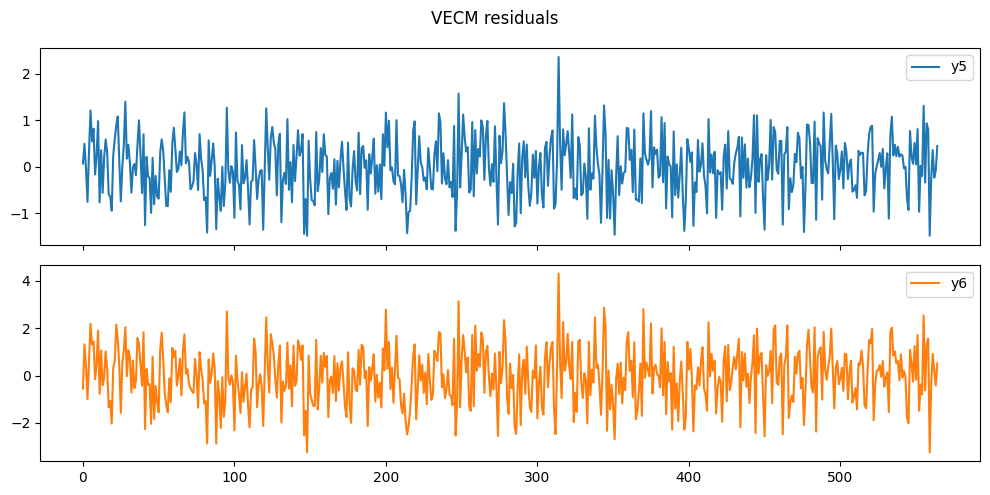

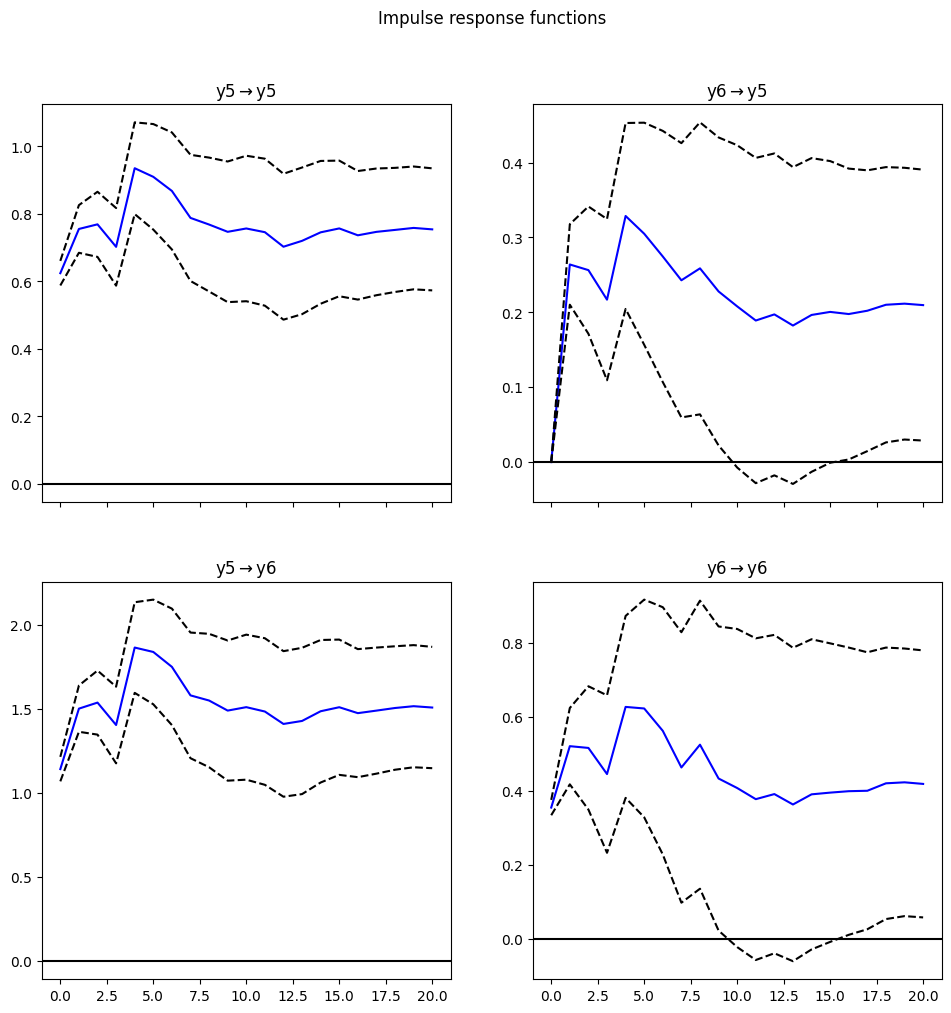

,shock y5,shock y6
y5,0.9197,0.0803
y6,0.9177,0.0823


In [10]:
# 10. VECM diagnostics, impulse response functions, and variance decomposition
# Diagnostics check whether the residuals behave reasonably.
# IRF and FEVD help explain the dynamic interaction between the two variables.

# Whiteness test: failing to reject the null suggests no strong residual autocorrelation
print(vecm_res.test_whiteness(nlags=12).summary())

# Normality test: failing to reject the null suggests no severe departure from normality
print(vecm_res.test_normality().summary())

# Plot residuals to check whether they fluctuate around zero
resid = pd.DataFrame(vecm_res.resid, columns=pair)
resid.plot(subplots=True, figsize=(10, 5), title="VECM residuals")
plt.tight_layout()
plt.show()

# IRF shows how a shock to one variable affects itself and the other variable over time
irf = vecm_res.irf(20)
irf.plot(orth=True)
plt.suptitle("Impulse response functions", y=1.02)
plt.show()

# FEVD shows which variable's shocks explain more of the forecast error variance
orth_irfs = irf.orth_irfs
h = 20
contrib = (orth_irfs[:h + 1] ** 2).sum(axis=0)
fevd = contrib / contrib.sum(axis=1, keepdims=True)

fevd_table = pd.DataFrame(
    fevd,
    index=pair,
    columns=[f"shock {col}" for col in pair]
)

fevd_table.round(4)


            y5_VECM_forecast  y6_VECM_forecast
date                                          
2025-04-06        112.934887         86.386286
2025-04-07        113.274499         87.094720
2025-04-08        112.995768         86.570071
2025-04-09        113.166165         86.899045
2025-04-10        113.123082         86.790598


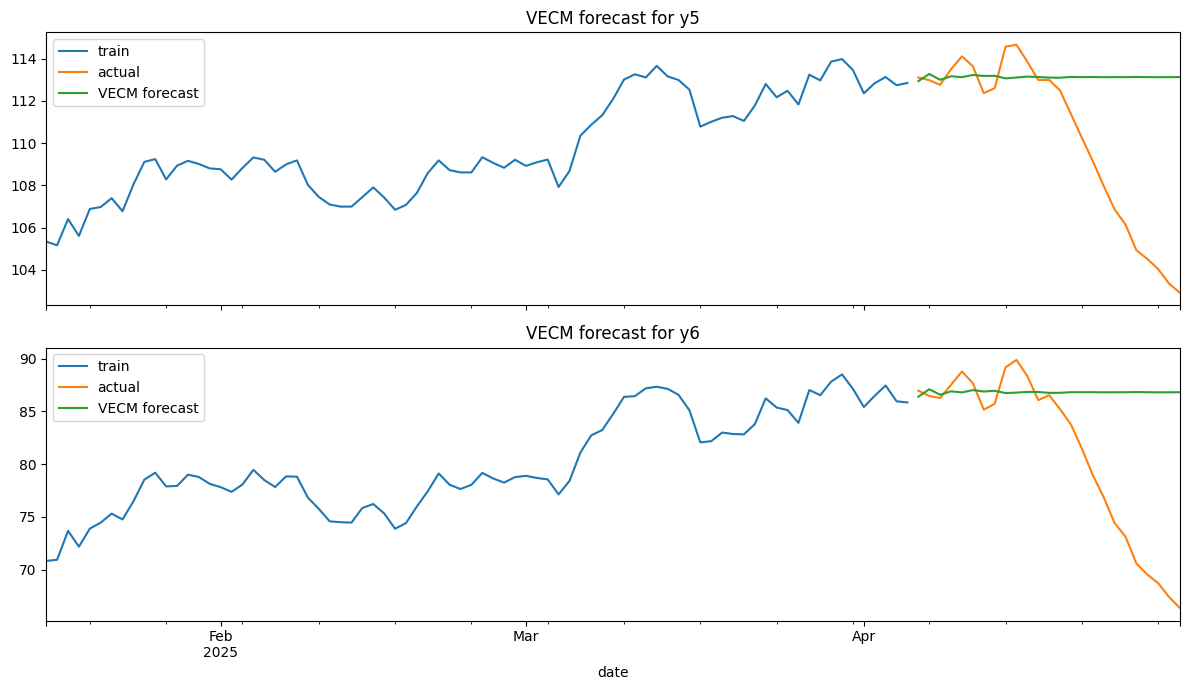

In [11]:
# 11. Forecast the 25 test observations using the VECM

vecm_forecast = pd.DataFrame(
    vecm_res.predict(steps=len(test)),
    index=test.index,
    columns=[f"{col}_VECM_forecast" for col in pair]
)

print(vecm_forecast.head())

# Plot the end of the training sample, the actual test values, and the VECM forecasts
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for i, col in enumerate(pair):
    train[col].iloc[-80:].plot(ax=axes[i], label="train")
    test[col].plot(ax=axes[i], label="actual")
    vecm_forecast[f"{col}_VECM_forecast"].plot(ax=axes[i], label="VECM forecast")

    axes[i].set_title(f"VECM forecast for {col}")
    axes[i].legend()

plt.tight_layout()
plt.show()


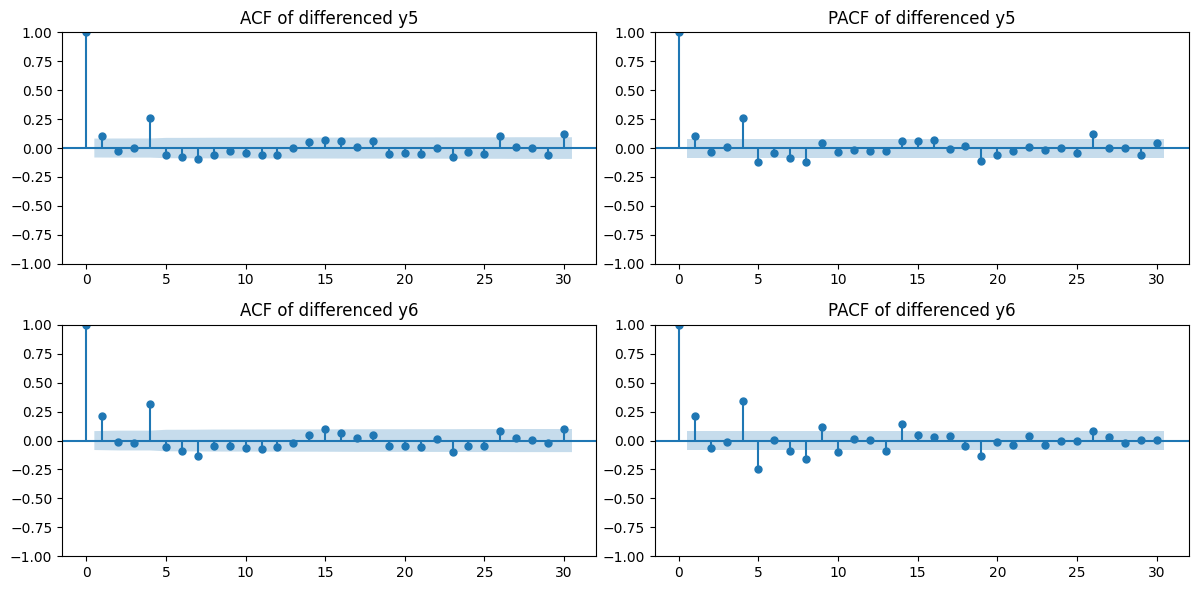

In [12]:
# 12. Plot ACF and PACF of the first-differenced series for ARIMA order selection
# Since the level series are non-stationary, the ARIMA differencing order d is set to 1.

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i, col in enumerate(pair):
    diff_series = train[col].diff().dropna()

    plot_acf(diff_series, ax=axes[i, 0], lags=30)
    axes[i, 0].set_title(f"ACF of differenced {col}")

    plot_pacf(diff_series, ax=axes[i, 1], lags=30)
    axes[i, 1].set_title(f"PACF of differenced {col}")

plt.tight_layout()
plt.show()


In [13]:
# 13. Select ARIMA models by AIC and generate forecasts
# ARIMA is a univariate model, so y5 and y6 are modeled separately as a benchmark against VECM.

from statsmodels.tsa.arima.model import ARIMA

# Candidate ARIMA orders: (p, d, q). Here d = 1 because the first differences are stationary.
orders = [(0,1,0), (1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2), (4,1,0), (0,1,4)]

best_arima = {}
arima_forecast = pd.DataFrame(index=test.index)

for col in pair:
    best_aic = 999999
    best_order = None
    best_result = None

    for order in orders:
        try:
            result = ARIMA(train[col], order=order).fit()

            if result.aic < best_aic:
                best_aic = result.aic
                best_order = order
                best_result = result

        except Exception:
            continue

    best_arima[col] = best_result
    arima_forecast[col] = best_result.forecast(steps=len(test))

    print(col, "best order:", best_order, "AIC:", round(best_aic, 2))

arima_forecast.head()


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  

y5 best order: (0, 1, 4) AIC: 1255.53
y6 best order: (0, 1, 4) AIC: 1852.48


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,y5,y6
date,,
2025-04-06,113.026034,86.232934
2025-04-07,113.081259,86.328686
2025-04-08,113.045680,86.124779
2025-04-09,113.170088,86.232031
2025-04-10,113.170088,86.232031


In [14]:
# 14. Compare the forecasting accuracy of VECM and ARIMA
# RMSE and MAE are both error measures; smaller values indicate better forecasts.

score_rows = []

for col in pair:
    actual = test[col]
    vecm_pred = vecm_forecast[f"{col}_VECM_forecast"]
    arima_pred = arima_forecast[col]

    score_rows.append({
        "series": col,
        "VECM RMSE": np.sqrt(((actual - vecm_pred) ** 2).mean()),
        "ARIMA RMSE": np.sqrt(((actual - arima_pred) ** 2).mean()),
        "VECM MAE": abs(actual - vecm_pred).mean(),
        "ARIMA MAE": abs(actual - arima_pred).mean()
    })

score_table = pd.DataFrame(score_rows).set_index("series")
score_table.round(4)


,VECM RMSE,ARIMA RMSE,VECM MAE,ARIMA MAE
series,,,,
y5,4.7943,4.8181,3.2568,3.2649
y6,9.4937,9.1637,6.4406,6.2144
